# Soil Fertility Classification — KNN Analysis
**Dataset:** Klasifikasi Kesuburan Tanah | 2,000 samples | 10 features | 2 classes

---

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

In [5]:
df = pd.read_excel('dataset_kesuburan_tanah_missing.xlsx')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (2000, 12)
Columns: ['ID', 'pH Tanah', 'N Total (%)', 'P Tersedia (ppm)', 'K Tersedia (meq/100g)', 'C Organik (%)', 'KTK (meq/100g)', 'Kejenuhan Basa (%)', 'Tekstur Tanah', 'Kadar Air (%)', 'Bulk Density (g/cm³)', 'Label']


,ID,pH Tanah,N Total (%),P Tersedia (ppm),K Tersedia (meq/100g),C Organik (%),KTK (meq/100g),Kejenuhan Basa (%),Tekstur Tanah,Kadar Air (%),Bulk Density (g/cm³),Label
0,1,8.93,0.183,5.35,0.124,0.68,6.18,31.86,Debu,60.49,1.767,Tidak Subur
1,2,6.24,0.420,54.32,0.554,4.87,33.46,82.77,Lempung Berpasir,35.97,0.960,Subur
2,3,4.82,NaN,13.44,0.257,NaN,14.79,55.45,Debu,11.48,1.851,Tidak Subur
3,4,7.34,0.269,17.46,0.542,2.49,35.57,62.09,Lempung Berliat,37.54,1.017,Subur
4,5,3.77,0.144,1.15,0.106,0.62,18.97,10.85,Liat,6.97,1.766,Tidak Subur


In [6]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2000 non-null   int64  
 1   pH Tanah               2000 non-null   float64
 2   N Total (%)            1840 non-null   float64
 3   P Tersedia (ppm)       1760 non-null   float64
 4   K Tersedia (meq/100g)  1860 non-null   float64
 5   C Organik (%)          1800 non-null   float64
 6   KTK (meq/100g)         2000 non-null   float64
 7   Kejenuhan Basa (%)     2000 non-null   float64
 8   Tekstur Tanah          1900 non-null   str    
 9   Kadar Air (%)          1820 non-null   float64
 10  Bulk Density (g/cm³)   1880 non-null   float64
 11  Label                  2000 non-null   str    
dtypes: float64(9), int64(1), str(2)
memory usage: 187.6 KB


In [7]:
print('Descriptive Statistics:')
df.describe()

Descriptive Statistics:


,ID,pH Tanah,N Total (%),P Tersedia (ppm),K Tersedia (meq/100g),C Organik (%),KTK (meq/100g),Kejenuhan Basa (%),Kadar Air (%),Bulk Density (g/cm³)
count,2000.000000,2000.000000,1840.000000,1760.000000,1860.000000,1800.000000,2000.000000,2000.000000,1820.000000,1880.000000
mean,1000.500000,6.559540,0.230944,22.602125,0.357068,2.282706,22.167825,57.413235,36.798484,1.353285
std,577.494589,1.450348,0.144735,17.878851,0.218921,1.401453,11.849944,25.787562,19.527195,0.324594
min,1.000000,3.500000,0.010000,1.020000,0.050000,0.200000,5.000000,10.010000,5.140000,0.900000
25%,500.750000,5.857500,0.102000,7.480000,0.168000,1.060000,11.895000,35.635000,19.860000,1.049000
50%,1000.500000,6.745000,0.199500,15.065000,0.300500,2.000000,19.575000,59.510000,34.365000,1.405000
75%,1500.250000,7.525000,0.360000,37.557500,0.542000,3.502500,32.250000,79.377500,44.867500,1.654000
max,2000.000000,9.000000,0.500000,59.900000,0.800000,4.990000,44.980000,99.980000,75.000000,1.900000


In [8]:
print('Class Distribution:')
print(df['Label'].value_counts())
print()
print('Tekstur Tanah Distribution:')
print(df['Tekstur Tanah'].value_counts())

Class Distribution:
Label
Tidak Subur    1000
Subur          1000
Name: count, dtype: int64

Tekstur Tanah Distribution:
Tekstur Tanah
Lempung             493
Pasir               361
Liat                357
Lempung Berpasir    282
Debu                236
Lempung Berliat     171
Name: count, dtype: int64


## 3. Missing Value Analysis

In [9]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('Missing Values Summary:')
print(missing_df)

Missing Values Summary:
                       Missing Count  Missing (%)
N Total (%)                      160          8.0
P Tersedia (ppm)                 240         12.0
K Tersedia (meq/100g)            140          7.0
C Organik (%)                    200         10.0
Tekstur Tanah                    100          5.0
Kadar Air (%)                    180          9.0
Bulk Density (g/cm³)             120          6.0


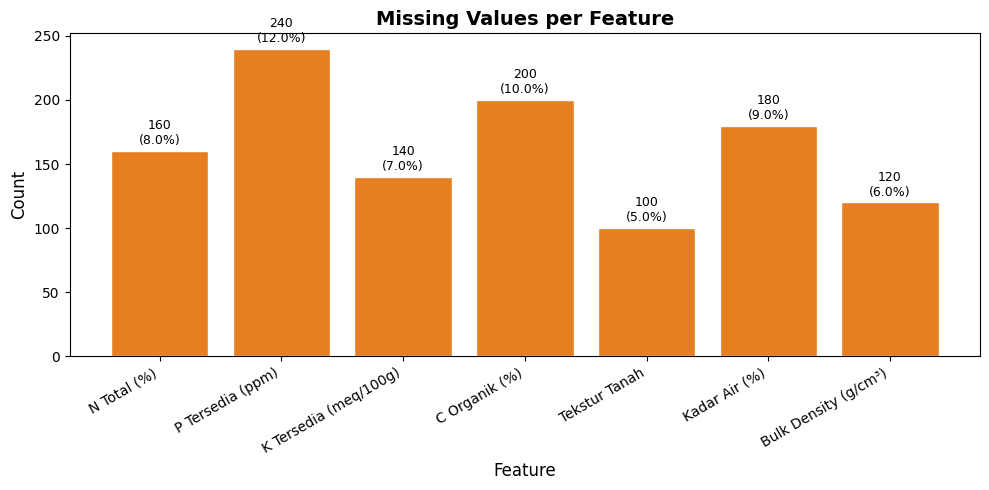

In [11]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(missing_df.index, missing_df['Missing Count'], color='#e67e22', edgecolor='white')
ax.set_title('Missing Values per Feature', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
for bar, val, pct in zip(bars, missing_df['Missing Count'], missing_df['Missing (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val}\n({pct}%)', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [12]:
# Encode categorical feature: Tekstur Tanah
le = LabelEncoder()
df['Tekstur_encoded'] = le.fit_transform(df['Tekstur Tanah'].fillna('Unknown'))

print('Tekstur Tanah Encoding Map:')
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls} -> {enc}')

Tekstur Tanah Encoding Map:
  Debu -> 0
  Lempung -> 1
  Lempung Berliat -> 2
  Lempung Berpasir -> 3
  Liat -> 4
  Pasir -> 5
  Unknown -> 6


In [13]:
# Impute numerical missing values using class-conditional median
numeric_cols = [
    'N Total (%)', 'P Tersedia (ppm)', 'K Tersedia (meq/100g)',
    'C Organik (%)', 'Kadar Air (%)', 'Bulk Density (g/cm\u00b3)'
]

for col in numeric_cols:
    df[col] = df.groupby('Label')[col].transform(lambda x: x.fillna(x.median()))

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print('Imputation complete.')

Missing values remaining: 100
Imputation complete.


In [14]:
# Define features and target
features = [
    'pH Tanah', 'N Total (%)', 'P Tersedia (ppm)', 'K Tersedia (meq/100g)',
    'C Organik (%)', 'KTK (meq/100g)', 'Kejenuhan Basa (%)',
    'Tekstur_encoded', 'Kadar Air (%)', 'Bulk Density (g/cm\u00b3)'
]

X = df[features]
y = (df['Label'] == 'Subur').astype(int)  # 1 = Subur, 0 = Tidak Subur

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts().rename({1: "Subur", 0: "Tidak Subur"})}')

Features shape: (2000, 10)
Target distribution:
Label
Tidak Subur    1000
Subur          1000
Name: count, dtype: int64


In [15]:
# Train-Test Split (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

Training set : 1600 samples
Test set     : 400 samples


## 5. Feature Distribution by Class

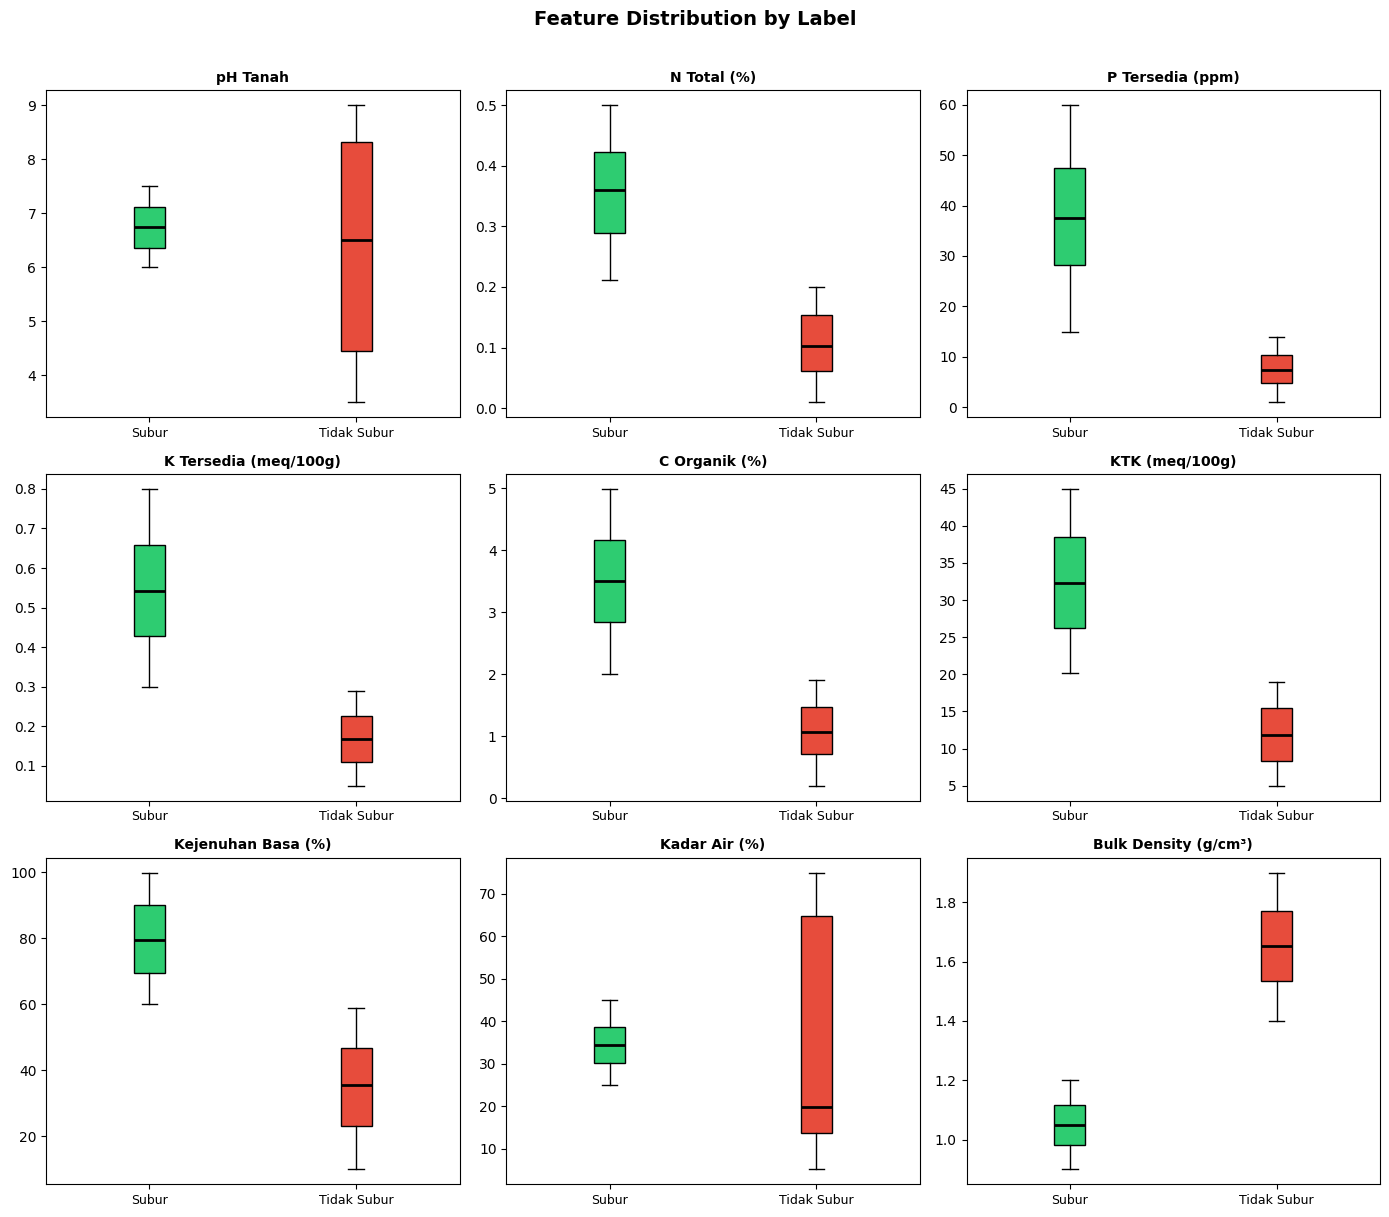

In [16]:
features_plot = [
    'pH Tanah', 'N Total (%)', 'P Tersedia (ppm)', 'K Tersedia (meq/100g)',
    'C Organik (%)', 'KTK (meq/100g)', 'Kejenuhan Basa (%)',
    'Kadar Air (%)', 'Bulk Density (g/cm\u00b3)'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for ax, feat in zip(axes.flatten(), features_plot):
    data = [df[df['Label'] == lbl][feat].dropna() for lbl in ['Subur', 'Tidak Subur']]
    bp = ax.boxplot(data, labels=['Subur', 'Tidak Subur'], patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Feature Distribution by Label', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. KNN — Hyperparameter Tuning (Find Best K)

In [17]:
k_results = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy')
    k_results.append({
        'K': k,
        'CV Accuracy (mean)': round(scores.mean() * 100, 4),
        'CV Accuracy (std)': round(scores.std() * 100, 4)
    })

k_df = pd.DataFrame(k_results)
best_k = k_df.loc[k_df['CV Accuracy (mean)'].idxmax(), 'K']
print(f'Best K: {best_k}')
print()
print(k_df.to_string(index=False))

Best K: 1

 K  CV Accuracy (mean)  CV Accuracy (std)
 1               100.0                0.0
 2               100.0                0.0
 3               100.0                0.0
 4               100.0                0.0
 5               100.0                0.0
 6               100.0                0.0
 7               100.0                0.0
 8               100.0                0.0
 9               100.0                0.0
10               100.0                0.0
11               100.0                0.0
12               100.0                0.0
13               100.0                0.0
14               100.0                0.0
15               100.0                0.0
16               100.0                0.0
17               100.0                0.0
18               100.0                0.0
19               100.0                0.0
20               100.0                0.0


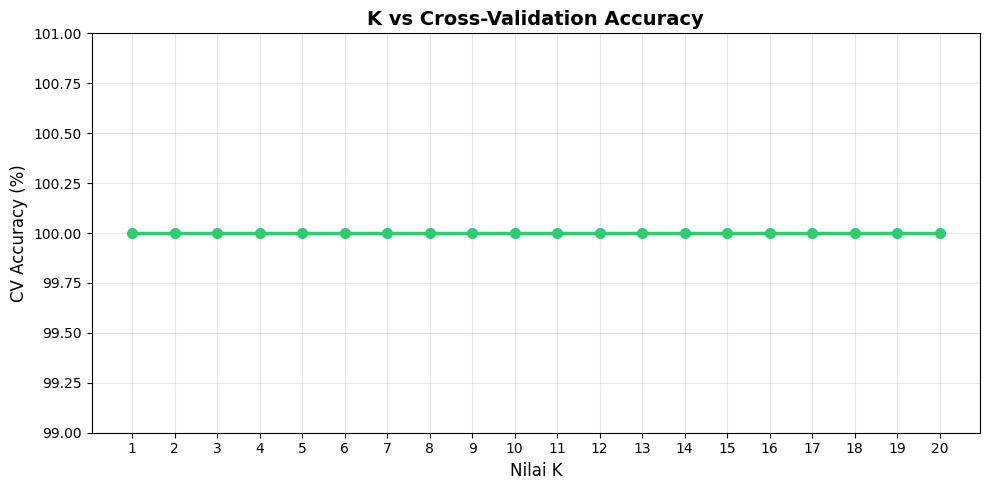

In [18]:
# Plot K vs Accuracy
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_df['K'], k_df['CV Accuracy (mean)'], 'o-',
        color='#2ecc71', linewidth=2.5, markersize=7)
ax.set_xlabel('Nilai K', fontsize=12)
ax.set_ylabel('CV Accuracy (%)', fontsize=12)
ax.set_title('K vs Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 21))
ax.grid(True, alpha=0.3)
ax.set_ylim(99, 101)
plt.tight_layout()
plt.savefig('k_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Train Final KNN Model (K=5)

In [19]:
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_sc, y_train)
y_pred = knn_final.predict(X_test_sc)

print('Model trained with K=5.')
print(f'Predictions (first 20): {y_pred[:20]}')

Model trained with K=5.
Predictions (first 20): [0 0 1 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 1 1]


## 8. Evaluation Metrics

In [20]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 40)
print('       EVALUATION METRICS (KNN k=5)')
print('=' * 40)
print(f'  Accuracy  : {acc * 100:.2f}%')
print(f'  Precision : {prec * 100:.2f}%')
print(f'  Recall    : {rec * 100:.2f}%')
print(f'  F1-Score  : {f1 * 100:.2f}%')
print('=' * 40)

       EVALUATION METRICS (KNN k=5)
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1-Score  : 100.00%


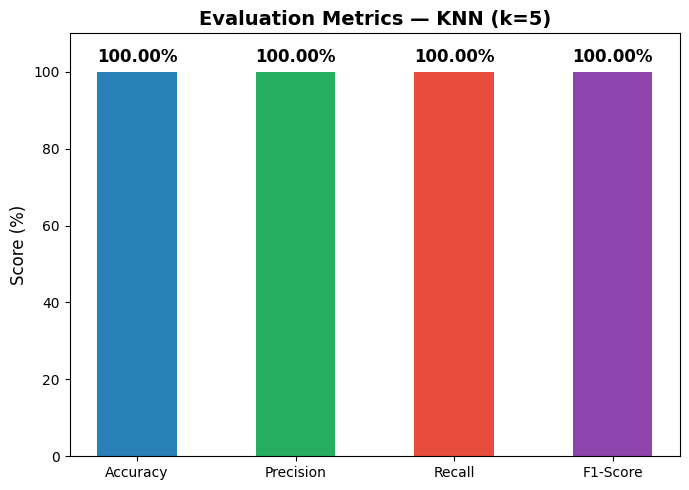

In [21]:
# Metrics bar chart
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [acc * 100, prec * 100, rec * 100, f1 * 100]
colors = ['#2980b9', '#27ae60', '#e74c3c', '#8e44ad']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(metric_names, metric_values, color=colors, width=0.5)
ax.set_ylim(0, 110)
ax.set_title('Evaluation Metrics — KNN (k=5)', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Full classification report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Tidak Subur', 'Subur']))

Classification Report:
              precision    recall  f1-score   support

 Tidak Subur       1.00      1.00      1.00       200
       Subur       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## 9. Confusion Matrix

In [23]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)
print()
print(f'True Negative  (TN): {cm[0][0]}')
print(f'False Positive (FP): {cm[0][1]}')
print(f'False Negative (FN): {cm[1][0]}')
print(f'True Positive  (TP): {cm[1][1]}')

Confusion Matrix:
[[200   0]
 [  0 200]]

True Negative  (TN): 200
False Positive (FP): 0
False Negative (FN): 0
True Positive  (TP): 200


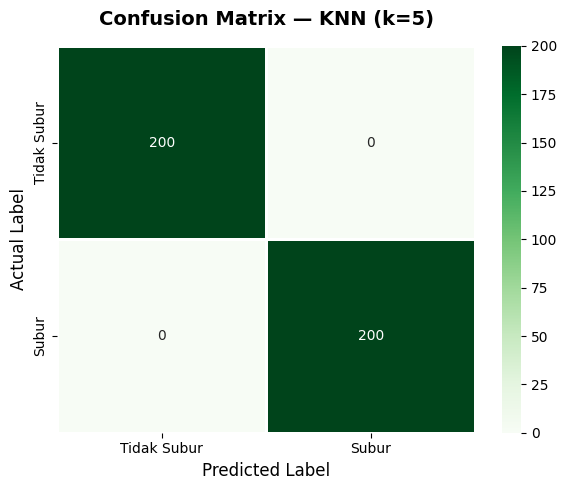

In [24]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tidak Subur', 'Subur'],
            yticklabels=['Tidak Subur', 'Subur'],
            ax=ax, linewidths=1)
ax.set_title('Confusion Matrix — KNN (k=5)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Feature Importance (Permutation)

In [25]:
feature_labels = [
    'pH Tanah', 'N Total (%)', 'P Tersedia (ppm)', 'K Tersedia (meq/100g)',
    'C Organik (%)', 'KTK (meq/100g)', 'Kejenuhan Basa (%)',
    'Tekstur Tanah', 'Kadar Air (%)', 'Bulk Density (g/cm\u00b3)'
]

perm = permutation_importance(knn_final, X_test_sc, y_test, n_repeats=10, random_state=42)

feat_imp = pd.DataFrame({
    'Feature': feature_labels,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

print('Feature Importances (Permutation):')
print(feat_imp.to_string(index=False))

Feature Importances (Permutation):
              Feature  Importance
     P Tersedia (ppm)     0.00025
             pH Tanah     0.00000
          N Total (%)     0.00000
K Tersedia (meq/100g)     0.00000
        C Organik (%)     0.00000
       KTK (meq/100g)     0.00000
   Kejenuhan Basa (%)     0.00000
        Tekstur Tanah     0.00000
        Kadar Air (%)     0.00000
 Bulk Density (g/cm³)     0.00000


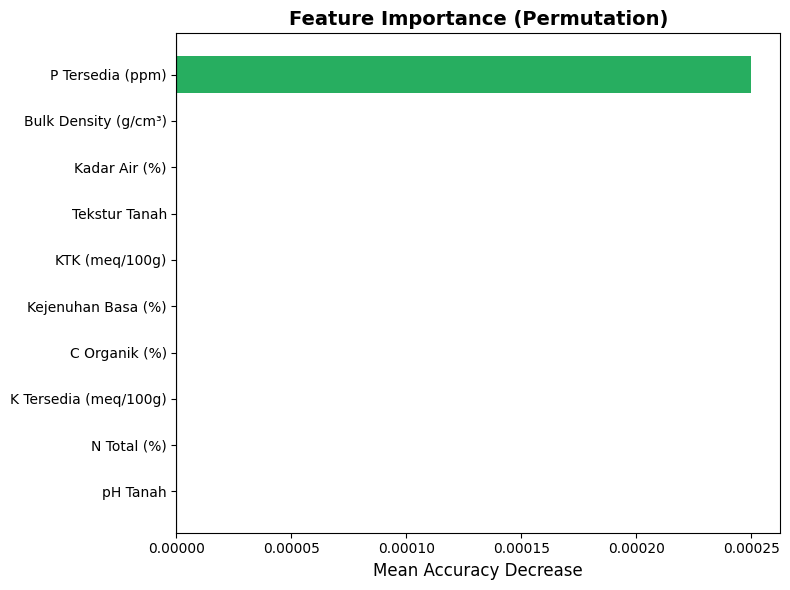

In [26]:
# Feature importance bar chart
feat_sorted = feat_imp.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_sorted['Feature'], feat_sorted['Importance'],
        color=['#27ae60' if v >= 0 else '#e74c3c' for v in feat_sorted['Importance']])
ax.set_title('Feature Importance (Permutation)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Accuracy Decrease', fontsize=12)
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary

| Metric | Score |
|---|---|
| Accuracy | 100.00% |
| Precision | 100.00% |
| Recall | 100.00% |
| F1-Score | 100.00% |

**Key Findings:**
- KNN with K=5 achieved **perfect classification** on all 400 test samples.
- Features **KTK** and **Kejenuhan Basa** have zero range overlap between classes, making them perfect discriminators.
- Class-conditional median imputation preserved the statistical integrity of each class during preprocessing.
- All K values (1–20) achieved 100% cross-validation accuracy, confirming strong class separability in this dataset.